In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

Load the data

In [2]:
df = pd.read_csv('datasets/model.csv')

df_capital = pd.read_csv('datasets/model_capital.csv')

gdf = gpd.read_file('datasets/mun_gis_data/mun_map_updated.gpkg') 

Merge province

In [3]:
# select observations for 2024
df_2024 = df[df['year'] == 2024].copy()

map_2024 = pd.merge(df_2024, gdf, on = 'prov', how = 'right')

# dissolve municipal boundaries
gdf_prov = gdf.dissolve(by='prov')

gdf_2024 = gdf_prov.merge(
    df_2024,
    on="prov",
    how="right"
)

Merge capitals

In [4]:
# select observations for 2024
df_2024_cap = df_capital[df_capital['year'] == 2024].copy()

map_2024 = pd.merge(df_2024_cap, gdf, on = 'prov', how = 'right')

# dissolve municipal boundaries
gdf_prov = gdf.dissolve(by='prov')

gdf_2024_cap = gdf_prov.merge(
    df_2024_cap,
    on="prov",
    how="right"
)

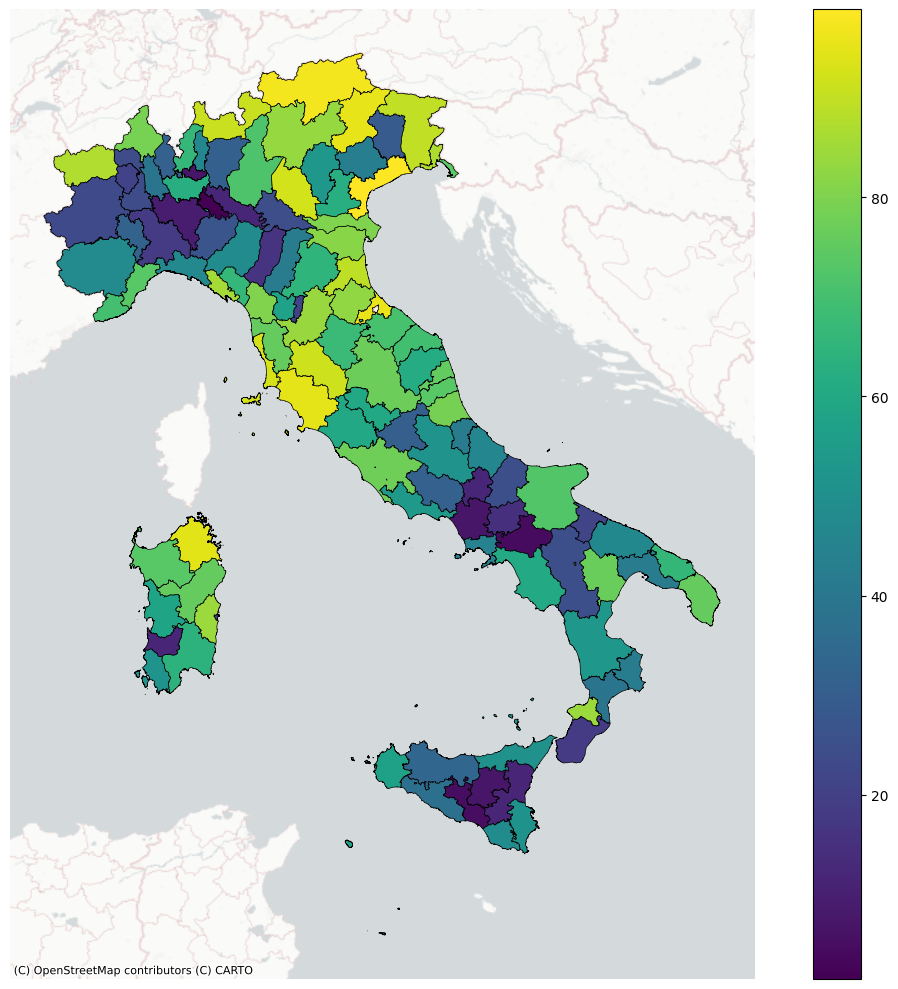

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="tourism_index_vdw",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

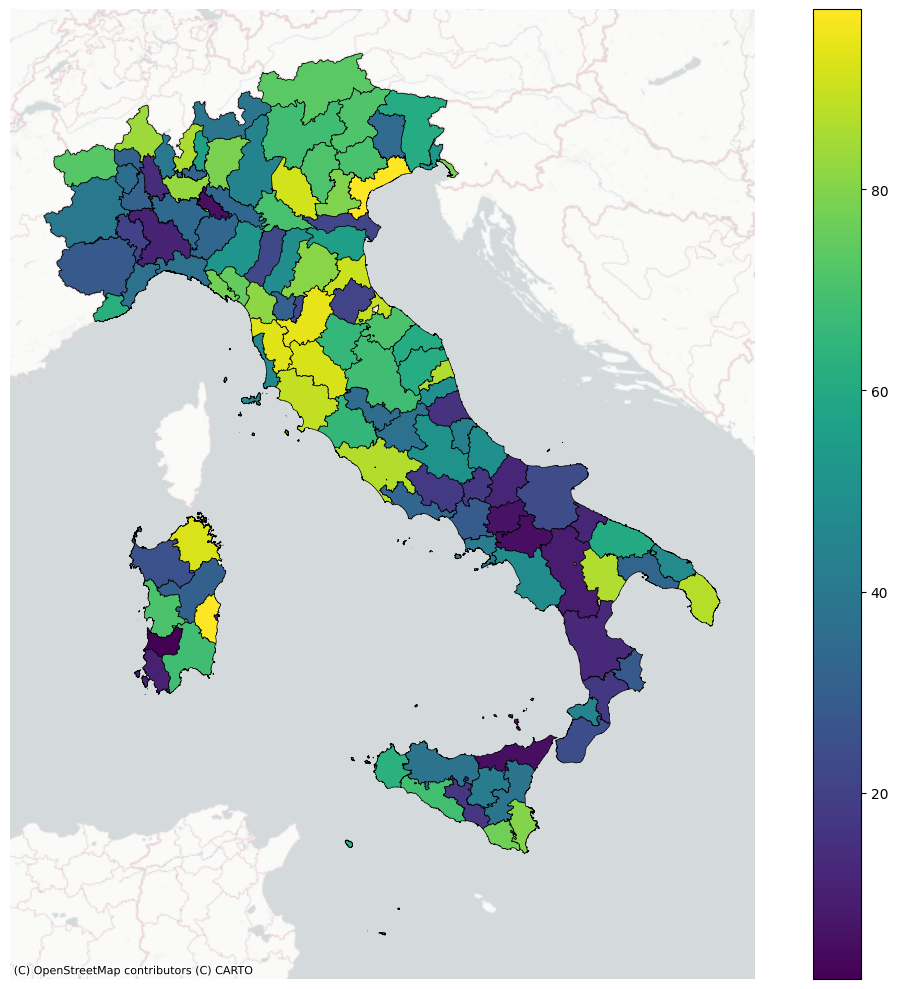

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="tourism_index_vdw",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()